In [5]:
from math import sqrt
import cv2
from skimage.feature import blob_dog, blob_log, blob_dog
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

In [6]:
# Load the color image
image = cv2.imread("animal.jpg",cv2.IMREAD_GRAYSCALE)

In [7]:
# Perform blob detection using LoG, DoG, and DoH
blobs_log = blob_log(image, max_sigma=30, num_sigma=10, threshold=0.05)
blobs_log[:, 2] = blobs_log[:, 2] * sqrt(2)  # Adjust radius for LoG

In [8]:
blobs_dog = blob_dog(image, max_sigma=30, threshold=0.05)
blobs_dog[:, 2] = blobs_dog[:, 2] * sqrt(2)  # Adjust radius for DoG


In [9]:
# Prepare visualization
blobs_list = [blobs_log, blobs_dog]
colors = ['yellow', 'lime']
titles = ['Laplacian of Gaussian (LoG)', 'Difference of Gaussian (DoG)']


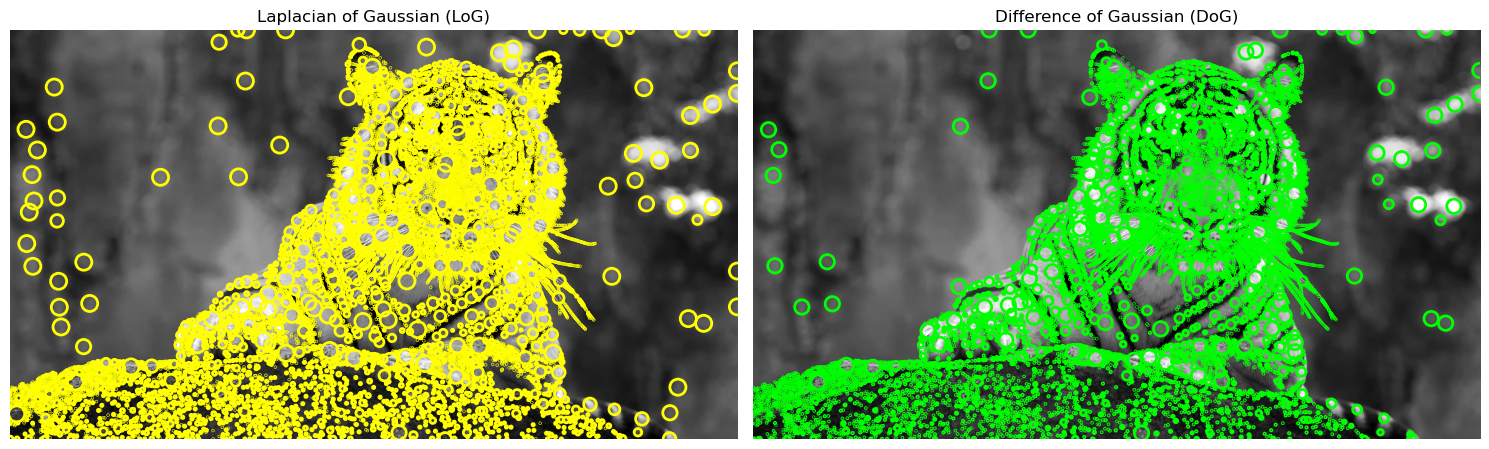

In [10]:
# Create subplots for visual comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True, sharey=True)
ax = axes.ravel()

for idx, (blobs, color, title) in enumerate(zip(blobs_list, colors, titles)):
    ax[idx].set_title(title)
    ax[idx].imshow(image,cmap='gray')
    for blob in blobs:
        y, x, r = blob
        c = plt.Circle((x, y), r, color=color, linewidth=2, fill=False)
        ax[idx].add_patch(c)
    ax[idx].set_axis_off()

plt.tight_layout()
plt.show()

In [12]:
params = cv2.SimpleBlobDetector_Params()

# Filter by area
params.filterByArea = True
params.minArea = 10 # Adjust to set minimum blob size
params.maxArea = 2000  # Adjust to set maximum blob size

In [13]:
# Filter by circularity
params.filterByCircularity = True
params.minCircularity = 0.5  # Adjust based on circularity of blobs (0 to 1)


In [14]:
# Filter by convexity
params.filterByConvexity = True
params.minConvexity = 0.7  # Adjust to filter convex blobs


In [15]:
# Filter by inertia (elongated shapes)
params.filterByInertia = True
params.minInertiaRatio = 0.3

In [16]:
# Create a blob detector with the parameters
detector = cv2.SimpleBlobDetector_create(params)

# Detect blobs
keypoints = detector.detect(image)

# Draw detected blobs as red circles
 # Convert to BGR for colored output
output_image = cv2.drawKeypoints(image, keypoints, None, (0, 0, 255),
                                 cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)


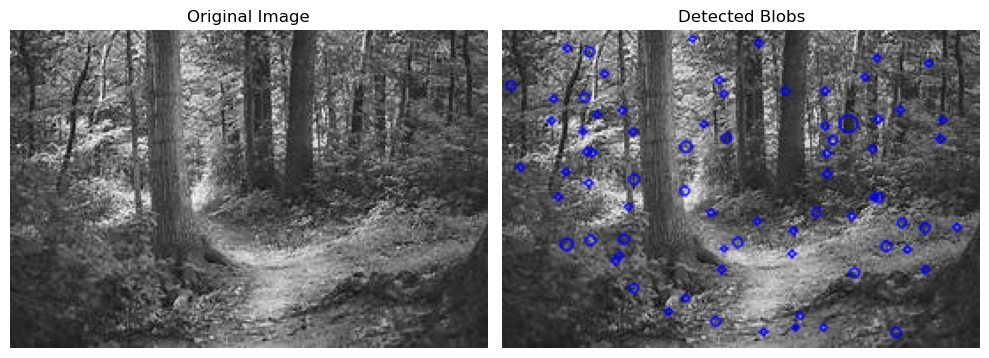

Number of blobs detected: 74
Blob 1: X=222.10, Y=170.78, Diameter=5.31
Blob 2: X=167.91, Y=161.35, Diameter=4.02
Blob 3: X=73.94, Y=145.79, Diameter=4.99
Blob 4: X=103.27, Y=151.36, Diameter=4.30
Blob 5: X=198.66, Y=136.96, Diameter=5.13
Blob 6: X=238.82, Y=135.30, Diameter=4.66
Blob 7: X=143.85, Y=107.98, Diameter=4.24
Blob 8: X=197.11, Y=105.19, Diameter=4.30
Blob 9: X=183.17, Y=81.30, Diameter=4.76
Blob 10: X=183.11, Y=69.81, Diameter=4.61
Blob 11: X=208.80, Y=67.16, Diameter=4.56
Blob 12: X=126.72, Y=60.94, Diameter=5.17
Blob 13: X=113.60, Y=53.30, Diameter=3.78
Blob 14: X=195.23, Y=53.03, Diameter=9.81
Blob 15: X=248.60, Y=50.88, Diameter=4.19
Blob 16: X=159.77, Y=34.61, Diameter=4.60
Blob 17: X=4.65, Y=31.59, Diameter=5.02
Blob 18: X=181.13, Y=168.03, Diameter=4.01
Blob 19: X=66.21, Y=127.18, Diameter=4.29
Blob 20: X=63.58, Y=130.47, Diameter=4.21
Blob 21: X=68.38, Y=118.07, Diameter=5.40
Blob 22: X=164.14, Y=113.34, Diameter=4.28
Blob 23: X=177.15, Y=103.09, Diameter=4.96
Blob 2

In [17]:
# Show the original and output images
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap="gray")
plt.axis("off")

# Image with Detected Blobs
plt.subplot(1, 2, 2)
plt.title("Detected Blobs")
plt.imshow(output_image)
plt.axis("off")

plt.tight_layout()
plt.show()

# Print blob information
print(f"Number of blobs detected: {len(keypoints)}")
for i, keypoint in enumerate(keypoints, 1):
    print(f"Blob {i}: X={keypoint.pt[0]:.2f}, Y={keypoint.pt[1]:.2f}, Diameter={keypoint.size:.2f}")

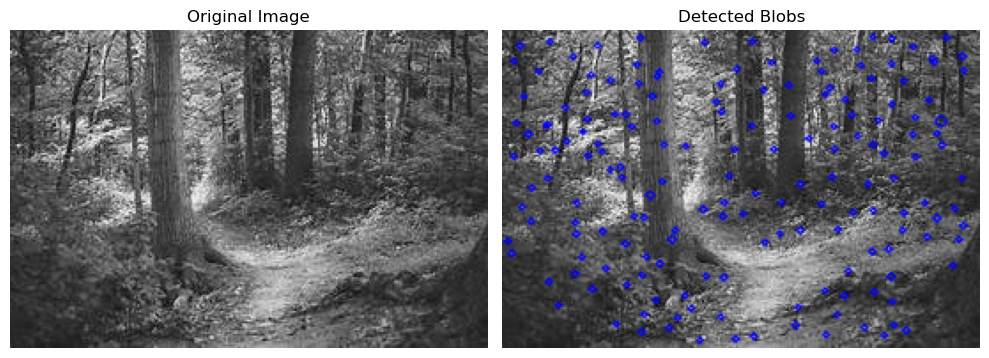

Number of blobs detected: 172
Blob 1: X=86.35, Y=152.23, Diameter=3.11
Blob 2: X=193.09, Y=150.15, Diameter=3.80
Blob 3: X=114.73, Y=138.97, Diameter=3.11
Blob 4: X=142.84, Y=92.37, Diameter=2.96
Blob 5: X=49.83, Y=25.41, Diameter=2.96
Blob 6: X=64.19, Y=165.99, Diameter=3.11
Blob 7: X=78.52, Y=170.35, Diameter=3.59
Blob 8: X=188.74, Y=160.81, Diameter=2.83
Blob 9: X=219.85, Y=153.53, Diameter=2.96
Blob 10: X=31.47, Y=155.28, Diameter=2.96
Blob 11: X=209.88, Y=147.73, Diameter=3.61
Blob 12: X=70.05, Y=143.81, Diameter=2.96
Blob 13: X=50.57, Y=146.29, Diameter=3.61
Blob 14: X=102.90, Y=149.94, Diameter=2.96
Blob 15: X=195.10, Y=135.98, Diameter=2.96
Blob 16: X=197.80, Y=102.99, Diameter=3.11
Blob 17: X=226.56, Y=103.34, Diameter=2.96
Blob 18: X=180.07, Y=98.34, Diameter=2.96
Blob 19: X=157.39, Y=97.29, Diameter=2.96
Blob 20: X=255.19, Y=100.81, Diameter=2.96
Blob 21: X=168.13, Y=87.34, Diameter=3.61
Blob 22: X=206.25, Y=87.02, Diameter=3.30
Blob 23: X=259.36, Y=83.76, Diameter=2.96
Blob

In [18]:
# Set up SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()

# Filter by area (size of blobs)
params.filterByArea = True
params.minArea = 5   # Adjust minimum size of blobs
params.maxArea = 5000   # Adjust maximum size of blobs

# Filter by thresholding (brightness)
params.minThreshold = 5   # Lower threshold for detection
params.maxThreshold = 100  # Upper threshold for detection

# Create a SimpleBlobDetector with the parameters
detector = cv2.SimpleBlobDetector_create(params)

# Detect blobs
keypoints = detector.detect(image)

# Draw detected blobs
output_image = cv2.drawKeypoints(image, keypoints, None, (0, 0, 255),
                                 cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)



# Display results
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(image, cmap="gray")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title("Detected Blobs")
plt.imshow(output_image)
plt.axis("off")

plt.tight_layout()
plt.show()

# Print blob details
print(f"Number of blobs detected: {len(keypoints)}")
for i, keypoint in enumerate(keypoints, 1):
    print(f"Blob {i}: X={keypoint.pt[0]:.2f}, Y={keypoint.pt[1]:.2f}, Diameter={keypoint.size:.2f}")

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# Load the color image
image_color = cv2.imread("animal_img.jpg")  # Replace with your image path


In [21]:
# Ensure the image is loaded properly
if image_color is None:
    raise ValueError("Image not found. Check the file path.")

In [22]:
# Convert the image to grayscale
image_gray = cv2.cvtColor(image_color, cv2.COLOR_BGR2GRAY)

# Set up SimpleBlobDetector parameters
params = cv2.SimpleBlobDetector_Params()

In [23]:
# Filter by area (size of blobs)
params.filterByArea = True
params.minArea = 10     # Adjust minimum size of blobs
params.maxArea = 1000    # Adjust maximum size of blobs

In [24]:
# Filter by thresholding (brightness)
params.minThreshold = 10   # Lower threshold for detection
params.maxThreshold = 200  # Upper threshold for detection

In [25]:
# Create a SimpleBlobDetector with the parameters
detector = cv2.SimpleBlobDetector_create(params)

# Detect blobs on the grayscale image
keypoints = detector.detect(image_gray)

# Draw detected blobs on the original color image
image_with_blobs = cv2.drawKeypoints(image_color, keypoints, None, (0, 0, 255),
                                     cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# Convert BGR to RGB for proper Matplotlib display
image_with_blobs_rgb = cv2.cvtColor(image_with_blobs, cv2.COLOR_BGR2RGB)


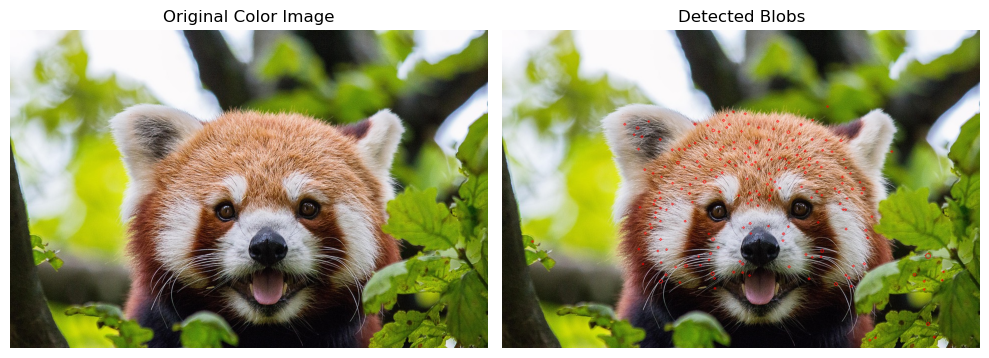

Number of blobs detected: 213
Blob 1: X=427.21, Y=519.84, Diameter=3.85
Blob 2: X=616.18, Y=500.62, Diameter=4.12
Blob 3: X=426.50, Y=499.68, Diameter=4.12
Blob 4: X=496.76, Y=494.16, Diameter=3.65
Blob 5: X=398.00, Y=473.50, Diameter=3.65
Blob 6: X=394.50, Y=456.00, Diameter=3.65
Blob 7: X=642.58, Y=444.80, Diameter=5.43
Blob 8: X=701.22, Y=515.56, Diameter=4.20
Blob 9: X=356.90, Y=508.08, Diameter=4.14
Blob 10: X=318.47, Y=505.74, Diameter=6.55
Blob 11: X=482.82, Y=488.18, Diameter=3.86
Blob 12: X=415.25, Y=462.50, Diameter=3.65
Blob 13: X=867.76, Y=617.44, Diameter=4.43
Blob 14: X=282.82, Y=471.09, Diameter=3.78
Blob 15: X=622.50, Y=457.50, Diameter=3.65
Blob 16: X=640.33, Y=456.67, Diameter=3.65
Blob 17: X=415.00, Y=410.50, Diameter=3.65
Blob 18: X=634.51, Y=387.46, Diameter=3.73
Blob 19: X=696.23, Y=498.89, Diameter=4.75
Blob 20: X=422.41, Y=490.32, Diameter=6.45
Blob 21: X=368.93, Y=474.70, Diameter=5.66
Blob 22: X=855.23, Y=591.34, Diameter=5.91
Blob 23: X=670.19, Y=511.23, Diam

In [26]:
# Display the original and processed images
plt.figure(figsize=(10, 5))

# Original Image
plt.subplot(1, 2, 1)
plt.title("Original Color Image")
plt.imshow(cv2.cvtColor(image_color, cv2.COLOR_BGR2RGB))
plt.axis("off")

# Image with Detected Blobs
plt.subplot(1, 2, 2)
plt.title("Detected Blobs")
plt.imshow(image_with_blobs_rgb)
plt.axis("off")

plt.tight_layout()
plt.show()

# Print blob details
print(f"Number of blobs detected: {len(keypoints)}")
for i, keypoint in enumerate(keypoints, 1):
    print(f"Blob {i}: X={keypoint.pt[0]:.2f}, Y={keypoint.pt[1]:.2f}, Diameter={keypoint.size:.2f}")

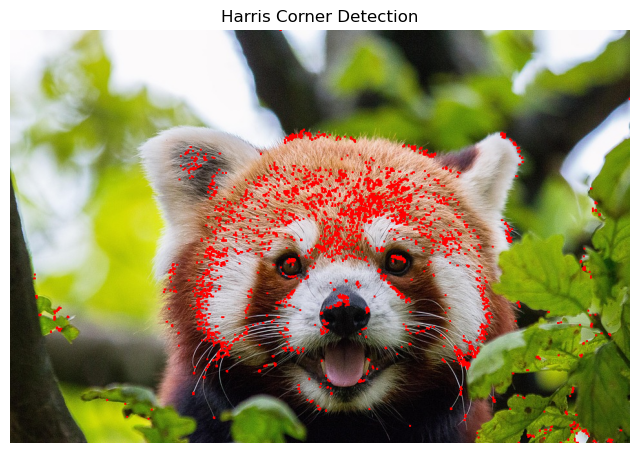

In [27]:
# Load the image
image = cv2.imread("animal_img.jpg")  # Replace with your image path
if image is None:
    raise ValueError("Image not found. Check the file path.")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply Harris Corner Detector
dst = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

# Dilate the detected corners for better visualization
dst = cv2.dilate(dst, None)

# Apply thresholding to highlight strong corners
threshold = 0.01 * dst.max()  # Adjust this value to experiment with corner strength
image[dst > threshold] = [0, 0, 255]  # Mark corners in red

# Convert BGR to RGB for proper Matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Harris Corner Detection")
plt.axis("off")
plt.show()

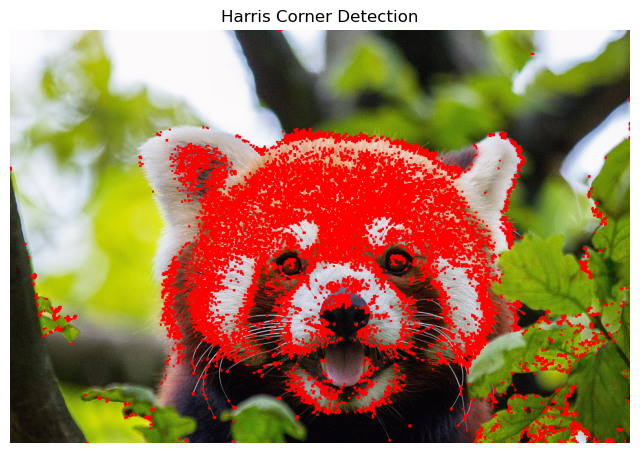

In [28]:
threshold = 0.001 * dst.max()  # Adjust this value to experiment with corner strength
image[dst > threshold] = [0, 0, 255]  # Mark corners in red

# Convert BGR to RGB for proper Matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title("Harris Corner Detection")
plt.axis("off")
plt.show()

C:\Users\Ayush\AppData\Local\Temp\ipykernel_24192\4013833637.py:14: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  corners = np.int0(corners)


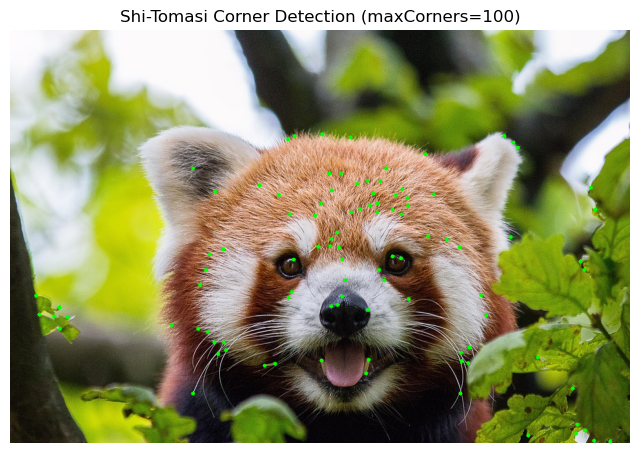

In [30]:
# Load the image
image = cv2.imread("animal_img.jpg")  # Replace with your image path
if image is None:
    raise ValueError("Image not found. Check the file path.")

# Convert to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Detect Shi-Tomasi corners
maxCorners = 100  # Modify this value to analyze the impact
corners = cv2.goodFeaturesToTrack(gray, maxCorners=maxCorners, qualityLevel=0.01, minDistance=10)

# Convert corners to integer values
corners = np.int0(corners)

# Draw corners on the image
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(image, (x, y), 3, (0, 255, 0), -1)  # Green circles for corners

# Convert BGR to RGB for proper Matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title(f"Shi-Tomasi Corner Detection (maxCorners={maxCorners})")
plt.axis("off")
plt.show()


C:\Users\Ayush\AppData\Local\Temp\ipykernel_24192\3987013895.py:5: DeprecationWarning: `np.int0` is a deprecated alias for `np.intp`.  (Deprecated NumPy 1.24)
  corners = np.int0(corners)


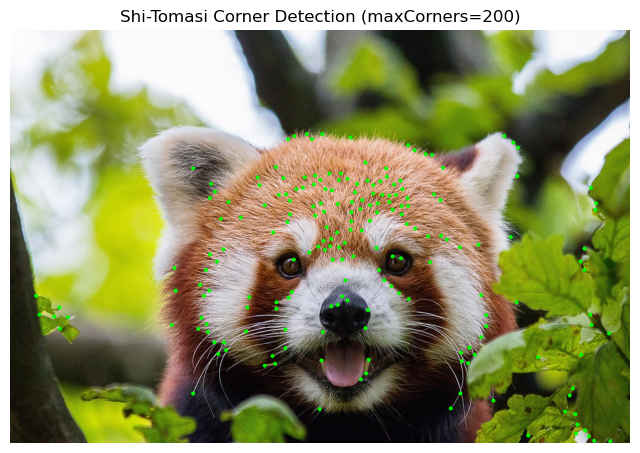

In [31]:
maxCorners = 200  # Modify this value to analyze the impact
corners = cv2.goodFeaturesToTrack(gray, maxCorners=maxCorners, qualityLevel=0.01, minDistance=10)

# Convert corners to integer values
corners = np.int0(corners)

# Draw corners on the image
for corner in corners:
    x, y = corner.ravel()
    cv2.circle(image, (x, y), 3, (0, 255, 0), -1)  # Green circles for corners

# Convert BGR to RGB for proper Matplotlib display
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Display results
plt.figure(figsize=(8, 6))
plt.imshow(image_rgb)
plt.title(f"Shi-Tomasi Corner Detection (maxCorners={maxCorners})")
plt.axis("off")
plt.show()